In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [13]:
customers=pd.read_csv("/content/Customers.csv")
order_items=pd.read_csv("/content/Order_Items.csv")
orders=pd.read_csv("/content/Orders (1).csv")
products=pd.read_csv("/content/Products.csv")
returns =pd.read_csv("/content/Returns.csv")
reviews=pd.read_csv("/content/Reviews.csv")

In [14]:
datasets = {
    "customers": customers,
    "order_items": order_items,
     "orders": orders,
    "products": products,
    "returns": returns,
    "reviews": reviews
}

In [15]:
for name, df in datasets.items():
    print(f"{name}: {df.shape}")

customers: (500, 8)
order_items: (2042, 7)
orders: (1250, 11)
products: (28, 11)
returns: (79, 6)
reviews: (494, 6)


In [16]:
for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(name)
    print(f"{'='*50}")
    display(df.head())


customers


,customer_id,customer_name,city,state,gender,age_group,signup_date,acquisition_channel
0,C0001,Ayaan Gupta,Hyderabad,Telangana,Female,35-44,08-09-2023,YouTube
1,C0002,Aarav Sharma,Gurugram,Haryana,Female,25-34,02-02-2023,Instagram
2,C0003,Kavya Kapoor,Noida,Uttar Pradesh,Other,18-24,23-07-2023,Google Search
3,C0004,Karan Mehta,Kochi,Kerala,Other,25-34,07-01-2023,YouTube
4,C0005,Vihaan Sharma,Lucknow,Uttar Pradesh,Male,18-24,11-12-2023,Google Search



order_items


,order_item_id,order_id,product_id,quantity,unit_price,discount_pct,item_total
0,OI000001,O00001,P023,1,499,15,424.15
1,OI000002,O00002,P020,1,349,0,349.00
2,OI000003,O00003,P001,2,549,10,988.20
3,OI000004,O00003,P002,1,599,20,479.20
4,OI000005,O00004,P009,2,349,5,663.10



orders


...

,product_id,product_name,category,concern,skin_type,key_ingredient,size,mrp,cost_price,stock_qty,launch_date
0,P001,2% Salicylic Acid Face Serum,Serum,Acne Control,Oily / Acne-Prone,Salicylic Acid,30ml,549,247,220,15-01-2022
1,P002,10% Niacinamide Face Serum,Serum,Oil Control,Oily / Combination,Niacinamide,30ml,599,265,240,10-09-2021
2,P003,Vitamin C 10% Face Serum,Serum,Brightening,All Skin Types,Vitamin C,30ml,699,315,180,01-05-2022
3,P004,Alpha Arbutin 2% Serum,Serum,Pigmentation,All Skin Types,Alpha Arbutin,30ml,649,292,160,18-03-2022
4,P005,Retinol 0.3% Face Serum,Serum,Anti-Ageing,Normal / Dry,Retinol,30ml,699,318,140,11-08-2022



returns


,return_id,order_id,product_id,return_date,return_reason,refund_status
0,R00001,O00011,P003,31-03-2024,Late delivery,Under Review
1,R00002,O00023,P007,17-05-2025,Skin irritation,Replacement Sent
2,R00003,O00032,P024,18-07-2024,Skin irritation,Refunded
3,R00004,O00062,P027,10-04-2024,Changed mind,Under Review
4,R00005,O00130,P017,26-08-2024,Skin irritation,Replacement Sent



reviews


,review_id,customer_id,product_id,order_id,rating,review_date
0,RV00001,C0047,P023,O00001,4,19-06-2024
1,RV00002,C0191,P001,O00003,5,08-12-2025
2,RV00003,C0087,P009,O00004,5,29-08-2025
3,RV00004,C0289,P007,O00009,1,17-06-2024
4,RV00005,C0476,P016,O00012,3,04-10-2025


In [17]:
for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * 50)
    df.info()


customers
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          500 non-null    object
 1   customer_name        500 non-null    object
 2   city                 500 non-null    object
 3   state                500 non-null    object
 4   gender               500 non-null    object
 5   age_group            500 non-null    object
 6   signup_date          500 non-null    object
 7   acquisition_channel  500 non-null    object
dtypes: object(8)
memory usage: 31.4+ KB

order_items
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2042 entries, 0 to 2041
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_item_id  2042 non-null   object 
 

In [18]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.columns.tolist())


customers
['customer_id', 'customer_name', 'city', 'state', 'gender', 'age_group', 'signup_date', 'acquisition_channel']

order_items
['order_item_id', 'order_id', 'product_id', 'quantity', 'unit_price', 'discount_pct', 'item_total']

orders
['order_id', 'customer_id', 'order_date', 'order_status', 'payment_method', 'sales_channel', 'gross_amount', 'discount_amount', 'shipping_fee', 'final_amount', 'delivered_date']

products
['product_id', 'product_name', 'category', 'concern', 'skin_type', 'key_ingredient', 'size', 'mrp', 'cost_price', 'stock_qty', 'launch_date']

returns
['return_id', 'order_id', 'product_id', 'return_date', 'return_reason', 'refund_status']

reviews
['review_id', 'customer_id', 'product_id', 'order_id', 'rating', 'review_date']


In [19]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.isnull().sum())


customers
customer_id            0
customer_name          0
city                   0
state                  0
gender                 0
age_group              0
signup_date            0
acquisition_channel    0
dtype: int64

order_items
order_item_id    0
order_id         0
product_id       0
quantity         0
unit_price       0
discount_pct     0
item_total       0
dtype: int64

orders
order_id             0
customer_id          0
order_date           0
order_status         0
payment_method       0
sales_channel        0
gross_amount         0
discount_amount      0
shipping_fee         0
final_amount         0
delivered_date     151
dtype: int64

products
product_id        0
product_name      0
category          0
concern           0
skin_type         0
key_ingredient    0
size              0
mrp               0
cost_price        0
stock_qty         0
launch_date       0
dtype: int64

returns
return_id        0
order_id         0
product_id       0
return_date      0
return_reason  

In [20]:
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")

customers: 0 duplicate rows
order_items: 0 duplicate rows
orders: 0 duplicate rows
products: 0 duplicate rows
returns: 0 duplicate rows
reviews: 0 duplicate rows


In [21]:
for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(name)
    print(f"{'='*50}")
    display(df.describe())


customers


,customer_id,customer_name,city,state,gender,age_group,signup_date,acquisition_channel
count,500,500,500,500,500,500,500,500
unique,500,339,20,13,3,4,353,5
top,C0500,Sai Kumar,Indore,Maharashtra,Female,25-34,12-03-2023,Google Search
freq,1,5,34,78,181,244,5,148



order_items


,quantity,unit_price,discount_pct,item_total
count,2042.000000,2042.000000,2042.000000,2042.000000
mean,1.262977,502.599412,9.603330,575.587659
std,0.522770,151.177064,7.219479,311.603978
min,1.000000,249.000000,0.000000,186.750000
25%,1.000000,399.000000,5.000000,359.100000
50%,1.000000,499.000000,10.000000,508.300000
75%,1.000000,599.000000,15.000000,664.050000
max,3.000000,799.000000,25.000000,2397.000000



orders


...

,mrp,cost_price,stock_qty
count,28.000000,28.000000,28.000000
mean,491.857143,212.535714,210.892857
std,154.389050,77.155198,63.129109
min,249.000000,92.000000,110.000000
25%,386.500000,154.750000,160.000000
50%,449.000000,194.500000,210.000000
75%,599.000000,265.250000,252.500000
max,799.000000,372.000000,350.000000



returns


,return_id,order_id,product_id,return_date,return_reason,refund_status
count,79,79,79,79,79,79
unique,79,79,25,75,5,3
top,R00001,O00011,P004,26-08-2024,Skin irritation,Replacement Sent
freq,1,1,9,2,28,28



reviews


,rating
count,494.000000
mean,3.914980
std,1.171353
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


In [22]:
for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(name)
    print(f"{'='*50}")
    display(df.describe(include='object'))


customers


,customer_id,customer_name,city,state,gender,age_group,signup_date,acquisition_channel
count,500,500,500,500,500,500,500,500
unique,500,339,20,13,3,4,353,5
top,C0500,Sai Kumar,Indore,Maharashtra,Female,25-34,12-03-2023,Google Search
freq,1,5,34,78,181,244,5,148



order_items


,order_item_id,order_id,product_id
count,2042,2042,2042
unique,2042,1250,28
top,OI002042,O00571,P004
freq,1,4,131



orders


...

,product_id,product_name,category,concern,skin_type,key_ingredient,size,launch_date
count,28,28,28,28,28,28,28,28
unique,28,28,9,19,14,25,8,28
top,P001,2% Salicylic Acid Face Serum,Serum,Exfoliation,All Skin Types,Salicylic Acid,30ml,15-01-2022
freq,1,1,8,3,9,3,8,1



returns


,return_id,order_id,product_id,return_date,return_reason,refund_status
count,79,79,79,79,79,79
unique,79,79,25,75,5,3
top,R00001,O00011,P004,26-08-2024,Skin irritation,Replacement Sent
freq,1,1,9,2,28,28



reviews


,review_id,customer_id,product_id,order_id,review_date
count,494,494,494,494,494
unique,494,309,28,494,355
top,RV00494,C0296,P004,O01250,20-08-2024
freq,1,5,38,1,5


In [23]:
orders[orders['delivered_date'].isnull()]['order_status'].value_counts()

,count
order_status,
Cancelled,86
In Transit,65


In [24]:
orders['order_status'].value_counts()

,count
order_status,
Delivered,1020
Cancelled,86
Returned,79
In Transit,65


In [26]:
customers['signup_date'] = pd.to_datetime(customers['signup_date'], dayfirst=True)

orders['order_date'] = pd.to_datetime(orders['order_date'], dayfirst=True)
orders['delivered_date'] = pd.to_datetime(orders['delivered_date'], dayfirst=True)

products['launch_date'] = pd.to_datetime(products['launch_date'], dayfirst=True)

returns['return_date'] = pd.to_datetime(returns['return_date'], dayfirst=True)

reviews['review_date'] = pd.to_datetime(reviews['review_date'], dayfirst=True)

In [27]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.dtypes)


customers
customer_id                    object
customer_name                  object
city                           object
state                          object
gender                         object
age_group                      object
signup_date            datetime64[ns]
acquisition_channel            object
dtype: object

order_items
order_item_id     object
order_id          object
product_id        object
quantity           int64
unit_price         int64
discount_pct       int64
item_total       float64
dtype: object

orders
order_id                   object
customer_id                object
order_date         datetime64[ns]
order_status               object
payment_method             object
sales_channel              object
gross_amount              float64
discount_amount           float64
shipping_fee                int64
final_amount              float64
delivered_date     datetime64[ns]
dtype: object

products
product_id                object
product_name              obje

# **Feature Engineering**

In [29]:
orders['order_year'] = orders['order_date'].dt.year
orders['order_month'] = orders['order_date'].dt.month_name()

orders['order_month_num'] = orders['order_date'].dt.month

In [31]:
orders['year_month'] = orders['year_month'].astype(str)

In [32]:
orders['delivery_time'] = (
    orders['delivered_date'] - orders['order_date']
).dt.days

In [33]:
orders[['order_date', 'delivered_date', 'delivery_time']].head()

,order_date,delivered_date,delivery_time
0,2024-06-10,2024-06-14,4.0
1,2025-02-18,2025-02-21,3.0
2,2025-12-03,2025-12-09,6.0
3,2025-08-10,2025-08-17,7.0
4,2025-07-17,2025-07-23,6.0


In [34]:
customers.columns

Index(['customer_id', 'customer_name', 'city', 'state', 'gender', 'age_group',
       'signup_date', 'acquisition_channel'],
      dtype='object')

In [35]:
orders['delivery_status'] = np.where(
    orders['order_status'] == 'Delivered',
    'Delivered',
    'Not Delivered'
)

In [36]:
orders.head()

,order_id,customer_id,order_date,order_status,payment_method,sales_channel,gross_amount,discount_amount,shipping_fee,final_amount,delivered_date,order_year,order_month,order_month_num,year_month,delivery_time,delivery_status
0,O00001,C0047,2024-06-10,Delivered,Debit Card,Mobile App,424.15,74.85,49,473.15,2024-06-14,2024,June,6,2024-06,4.0,Delivered
1,O00002,C0016,2025-02-18,Delivered,Credit Card,Website,349.00,0.00,40,389.00,2025-02-21,2025,February,2,2025-02,3.0,Delivered
2,O00003,C0191,2025-12-03,Delivered,Credit Card,Website,1467.40,229.60,0,1467.40,2025-12-09,2025,December,12,2025-12,6.0,Delivered
3,O00004,C0087,2025-08-10,Delivered,Credit Card,Website,663.10,34.90,49,712.10,2025-08-17,2025,August,8,2025-08,7.0,Delivered
4,O00005,C0211,2025-07-17,Delivered,UPI,Website,1511.35,134.65,0,1511.35,2025-07-23,2025,July,7,2025-07,6.0,Delivered


# **Data Merging**

In [37]:
sales_df = orders.merge(
    order_items,
    on='order_id',
    how='inner'
).merge(
    products,
    on='product_id',
    how='left'
)

sales_df.head()

,order_id,customer_id,order_date,order_status,payment_method,sales_channel,gross_amount,discount_amount,shipping_fee,final_amount,delivered_date,order_year,order_month,order_month_num,year_month,delivery_time,delivery_status,order_item_id,product_id,quantity,unit_price,discount_pct,item_total,product_name,category,concern,skin_type,key_ingredient,size,mrp,cost_price,stock_qty,launch_date
0,O00001,C0047,2024-06-10,Delivered,Debit Card,Mobile App,424.15,74.85,49,473.15,2024-06-14,2024,June,6,2024-06,4.0,Delivered,OI000001,P023,1,499,15,424.15,Anti-Dandruff Shampoo,Hair Care,Dandruff Control,Scalp Care,Piroctone Olamine,200ml,499,221,200,2022-11-21
1,O00002,C0016,2025-02-18,Delivered,Credit Card,Website,349.00,0.00,40,389.00,2025-02-21,2025,February,2,2025-02,3.0,Delivered,OI000002,P020,1,349,0,349.00,Rose Water Hydrating Toner,Toner,Hydration,All Skin Types,Rose Water,150ml,349,139,210,2023-06-17
2,O00003,C0191,2025-12-03,Delivered,Credit Card,Website,1467.40,229.60,0,1467.40,2025-12-09,2025,December,12,2025-12,6.0,Delivered,OI000003,P001,2,549,10,988.20,2% Salicylic Acid Face Serum,Serum,Acne Control,Oily / Acne-Prone,Salicylic Acid,30ml,549,247,220,2022-01-15
3,O00003,C0191,2025-12-03,Delivered,Credit Card,Website,1467.40,229.60,0,1467.40,2025-12-09,2025,December,12,2025-12,6.0,Delivered,OI000004,P002,1,599,20,479.20,10% Niacinamide Face Serum,Serum,Oil Control,Oily / Combination,Niacinamide,30ml,599,265,240,2021-09-10
4,O00004,C0087,2025-08-10,Delivered,Credit Card,Website,663.10,34.90,49,712.10,2025-08-17,2025,August,8,2025-08,7.0,Delivered,OI000005,P009,2,349,5,663.10,Ceramide Moisturizer,Moisturizer,Barrier Repair,Dry / Sensitive,Ceramide,50g,349,145,300,2022-10-01


In [38]:
sales_df.shape

(2042, 33)

In [39]:
sales_customer_df = sales_df.merge(
    customers,
    on='customer_id',
    how='left'
)

sales_customer_df.head()

,order_id,customer_id,order_date,order_status,payment_method,sales_channel,gross_amount,discount_amount,shipping_fee,final_amount,delivered_date,order_year,order_month,order_month_num,year_month,delivery_time,delivery_status,order_item_id,product_id,quantity,unit_price,discount_pct,item_total,product_name,category,concern,skin_type,key_ingredient,size,mrp,cost_price,stock_qty,launch_date,customer_name,city,state,gender,age_group,signup_date,acquisition_channel
0,O00001,C0047,2024-06-10,Delivered,Debit Card,Mobile App,424.15,74.85,49,473.15,2024-06-14,2024,June,6,2024-06,4.0,Delivered,OI000001,P023,1,499,15,424.15,Anti-Dandruff Shampoo,Hair Care,Dandruff Control,Scalp Care,Piroctone Olamine,200ml,499,221,200,2022-11-21,Ira Iyer,Vadodara,Gujarat,Female,18-24,2023-08-07,Instagram
1,O00002,C0016,2025-02-18,Delivered,Credit Card,Website,349.00,0.00,40,389.00,2025-02-21,2025,February,2,2025-02,3.0,Delivered,OI000002,P020,1,349,0,349.00,Rose Water Hydrating Toner,Toner,Hydration,All Skin Types,Rose Water,150ml,349,139,210,2023-06-17,Ira Mishra,Vadodara,Gujarat,Male,25-34,2023-05-22,Instagram
2,O00003,C0191,2025-12-03,Delivered,Credit Card,Website,1467.40,229.60,0,1467.40,2025-12-09,2025,December,12,2025-12,6.0,Delivered,OI000003,P001,2,549,10,988.20,2% Salicylic Acid Face Serum,Serum,Acne Control,Oily / Acne-Prone,Salicylic Acid,30ml,549,247,220,2022-01-15,Aditya Sharma,Nagpur,Maharashtra,Other,18-24,2024-03-30,Google Search
3,O00003,C0191,2025-12-03,Delivered,Credit Card,Website,1467.40,229.60,0,1467.40,2025-12-09,2025,December,12,2025-12,6.0,Delivered,OI000004,P002,1,599,20,479.20,10% Niacinamide Face Serum,Serum,Oil Control,Oily / Combination,Niacinamide,30ml,599,265,240,2021-09-10,Aditya Sharma,Nagpur,Maharashtra,Other,18-24,2024-03-30,Google Search
4,O00004,C0087,2025-08-10,Delivered,Credit Card,Website,663.10,34.90,49,712.10,2025-08-17,2025,August,8,2025-08,7.0,Delivered,OI000005,P009,2,349,5,663.10,Ceramide Moisturizer,Moisturizer,Barrier Repair,Dry / Sensitive,Ceramide,50g,349,145,300,2022-10-01,Nisha Jain,Mumbai,Maharashtra,Male,25-34,2024-02-04,Google Search


In [40]:
returns_df = returns.merge(
    products,
    on='product_id',
    how='left'
)

returns_df.head()

,return_id,order_id,product_id,return_date,return_reason,refund_status,product_name,category,concern,skin_type,key_ingredient,size,mrp,cost_price,stock_qty,launch_date
0,R00001,O00011,P003,2024-03-31,Late delivery,Under Review,Vitamin C 10% Face Serum,Serum,Brightening,All Skin Types,Vitamin C,30ml,699,315,180,2022-05-01
1,R00002,O00023,P007,2025-05-17,Skin irritation,Replacement Sent,AHA BHA 10% Exfoliating Serum,Serum,Exfoliation,Oily / Combination,AHA + BHA,30ml,699,322,130,2023-02-20
2,R00003,O00032,P024,2024-07-18,Skin irritation,Refunded,Hair Growth Actives Serum,Hair Care,Hair Growth,Scalp Care,Redensyl,60ml,799,372,160,2023-02-14
3,R00004,O00062,P027,2024-04-10,Changed mind,Under Review,Body Wash with Salicylic Acid,Body Care,Body Acne,Oily / Acne-Prone,Salicylic Acid,200ml,399,159,240,2023-11-01
4,R00005,O00130,P017,2024-08-26,Skin irritation,Replacement Sent,Oat Extract Gentle Cleanser,Cleanser,Gentle Cleansing,Sensitive / Dry,Oat Extract,100ml,299,121,290,2022-06-15


In [41]:
reviews_df = reviews.merge(
    products,
    on='product_id',
    how='left'
)

reviews_df.head()

,review_id,customer_id,product_id,order_id,rating,review_date,product_name,category,concern,skin_type,key_ingredient,size,mrp,cost_price,stock_qty,launch_date
0,RV00001,C0047,P023,O00001,4,2024-06-19,Anti-Dandruff Shampoo,Hair Care,Dandruff Control,Scalp Care,Piroctone Olamine,200ml,499,221,200,2022-11-21
1,RV00002,C0191,P001,O00003,5,2025-12-08,2% Salicylic Acid Face Serum,Serum,Acne Control,Oily / Acne-Prone,Salicylic Acid,30ml,549,247,220,2022-01-15
2,RV00003,C0087,P009,O00004,5,2025-08-29,Ceramide Moisturizer,Moisturizer,Barrier Repair,Dry / Sensitive,Ceramide,50g,349,145,300,2022-10-01
3,RV00004,C0289,P007,O00009,1,2024-06-17,AHA BHA 10% Exfoliating Serum,Serum,Exfoliation,Oily / Combination,AHA + BHA,30ml,699,322,130,2023-02-20
4,RV00005,C0476,P016,O00012,3,2025-10-04,Salicylic Acid Face Cleanser,Cleanser,Acne Control,Oily / Acne-Prone,Salicylic Acid,100ml,299,117,320,2021-08-16


In [42]:
print("Sales Data:", sales_df.shape)
print("Sales + Customer Data:", sales_customer_df.shape)
print("Returns Data:", returns_df.shape)
print("Reviews Data:", reviews_df.shape)

Sales Data: (2042, 33)
Sales + Customer Data: (2042, 40)
Returns Data: (79, 16)
Reviews Data: (494, 16)


# **Sales analysis**

# **1.KPIs**

In [43]:
total_sales = orders['final_amount'].sum()

total_orders = orders['order_id'].nunique()

total_customers = customers['customer_id'].nunique()

average_order_value = total_sales / total_orders

total_quantity_sold = order_items['quantity'].sum()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Order Value: ${average_order_value:,.2f}")
print(f"Total Quantity Sold: {total_quantity_sold:,}")

Total Sales: $1,122,034.65
Total Orders: 1,250
Total Customers: 500
Average Order Value: $897.63
Total Quantity Sold: 2,579


# **2. Sales Trend Over Time 📈**

In [44]:
monthly_sales = (
    orders.groupby('year_month')['final_amount']
    .sum()
    .reset_index()
)

monthly_sales

,year_month,final_amount
0,2024-01,38805.60
1,2024-02,30858.75
2,2024-03,47576.60
3,2024-04,42484.00
4,2024-05,39458.40
5,2024-06,43738.35
6,2024-07,32730.95
7,2024-08,83867.60
8,2024-09,32624.35
9,2024-10,84795.45


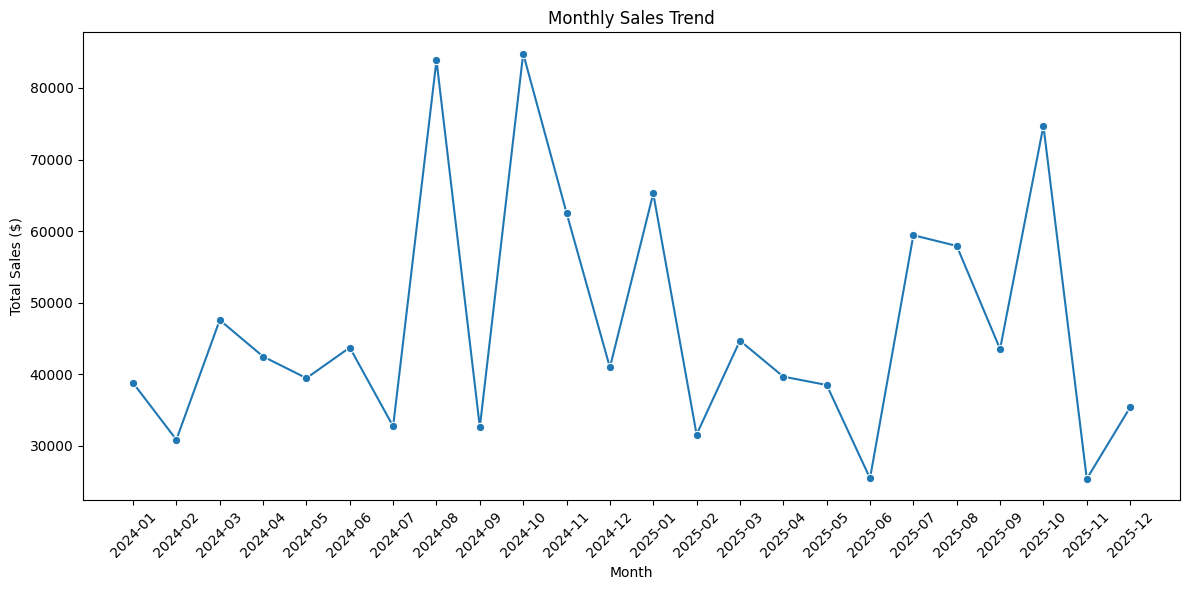

In [45]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_sales,
    x='year_month',
    y='final_amount',
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# **3. Sales by Product Category**

In [59]:
sales_customer_df['item_sales'] = (
    sales_customer_df['quantity'] * sales_customer_df['unit_price']
)

In [46]:
sales_df['item_sales'] = (
    sales_df['quantity'] * sales_df['unit_price']
)

In [47]:
category_sales = (
    sales_df.groupby('category')['item_sales']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_sales

,category,item_sales
0,Serum,598031
1,Moisturizer,171607
2,Sunscreen,143786
3,Hair Care,142084
4,Cleanser,91264
5,Body Care,55022
6,Eye Care,48189
7,Toner,29620
8,Lip Care,20418


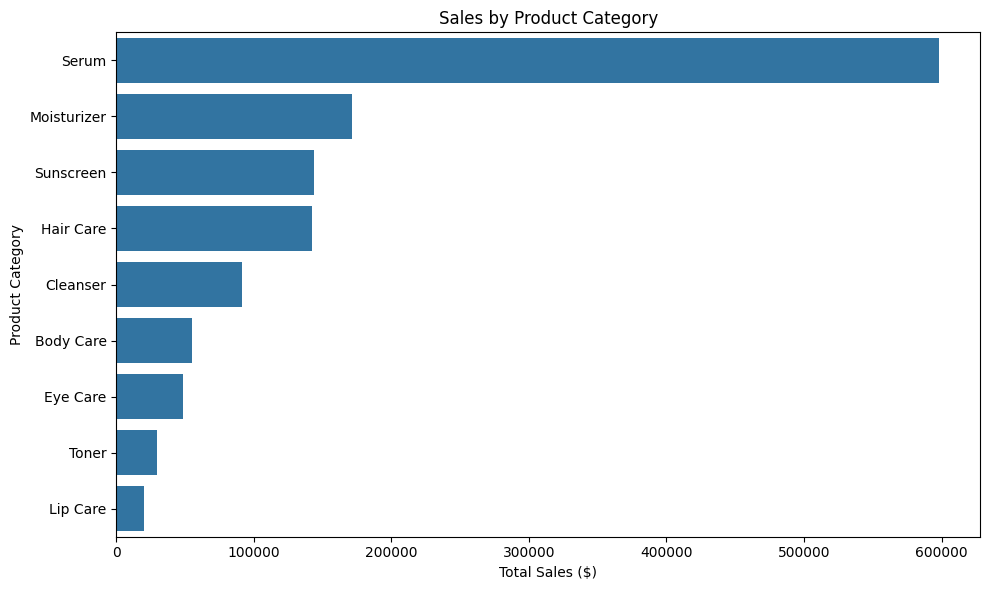

In [48]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_sales,
    x='item_sales',
    y='category'
)

plt.title('Sales by Product Category')
plt.xlabel('Total Sales ($)')
plt.ylabel('Product Category')
plt.tight_layout()

plt.show()

# **4. Sales by Sales Channel**

In [49]:
channel_sales = (
    orders.groupby('sales_channel')['final_amount']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

channel_sales

,sales_channel,final_amount
0,Website,615584.95
1,Mobile App,409956.60
2,Marketplace,96493.10


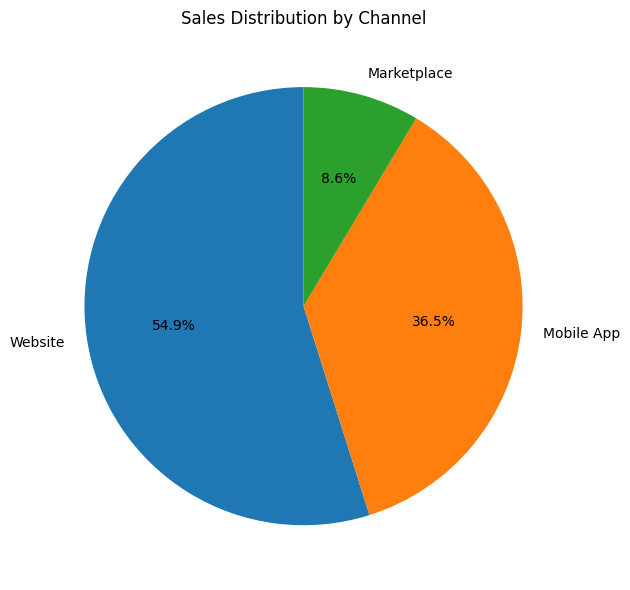

In [50]:
plt.figure(figsize=(8, 6))

plt.pie(
    channel_sales['final_amount'],
    labels=channel_sales['sales_channel'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Sales Distribution by Channel')
plt.tight_layout()

plt.show()

# **5. Orders by Status**

In [51]:
order_status = (
    orders['order_status']
    .value_counts()
    .reset_index()
)

order_status.columns = ['order_status', 'count']

order_status

,order_status,count
0,Delivered,1020
1,Cancelled,86
2,Returned,79
3,In Transit,65


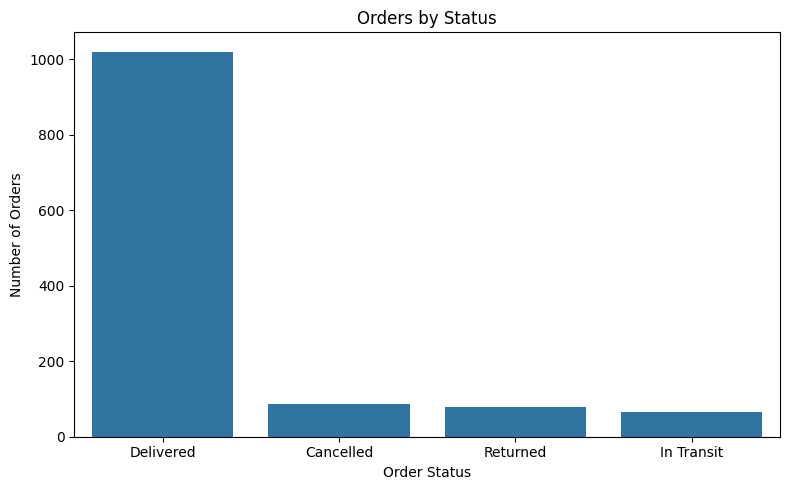

In [52]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=order_status,
    x='order_status',
    y='count'
)

plt.title('Orders by Status')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

# **Customer & Product Analysis 👥🧴**


Q1.**Which states generate the highest sales?** (sales by state)


In [60]:
state_sales = (
    sales_customer_df.groupby('state')['item_sales']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

state_sales

,state,item_sales
0,Maharashtra,246124
1,Gujarat,191368
2,Madhya Pradesh,155594
3,Uttar Pradesh,147899
4,Tamil Nadu,92965
5,Kerala,75751
6,Haryana,66961
7,Rajasthan,66667
8,Karnataka,60730
9,Telangana,57832


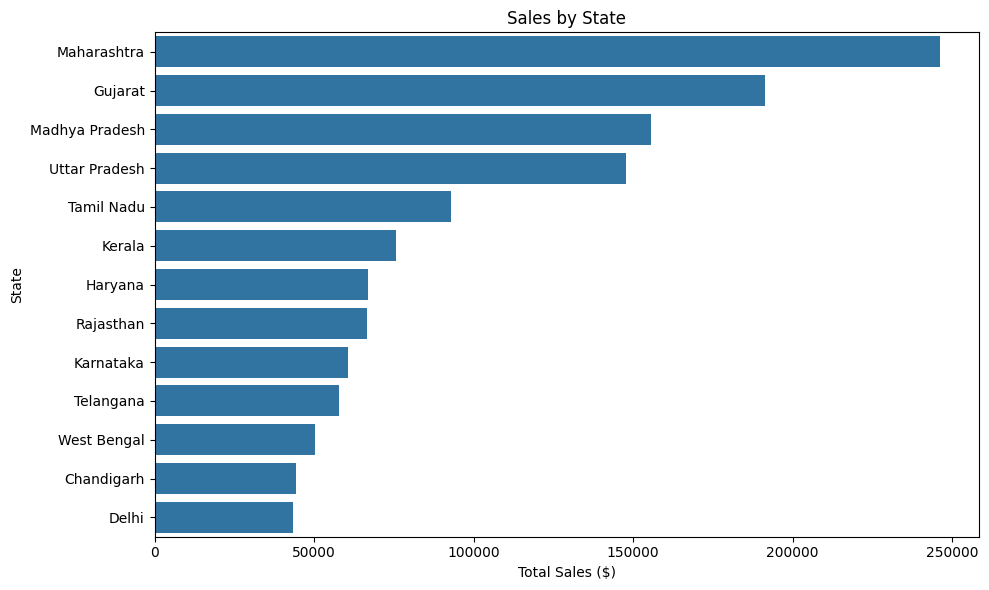

In [61]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=state_sales,
    x='item_sales',
    y='state'
)

plt.title('Sales by State')
plt.xlabel('Total Sales ($)')
plt.ylabel('State')

plt.tight_layout()
plt.show()

Q2.**Which age group has the highest number of customers?**(Customer by age gap)

In [62]:
age_group_customers = (
    customers['age_group']
    .value_counts()
    .reset_index()
)

age_group_customers.columns = ['age_group', 'customer_count']

age_group_customers

,age_group,customer_count
0,25-34,244
1,18-24,120
2,35-44,86
3,45+,50


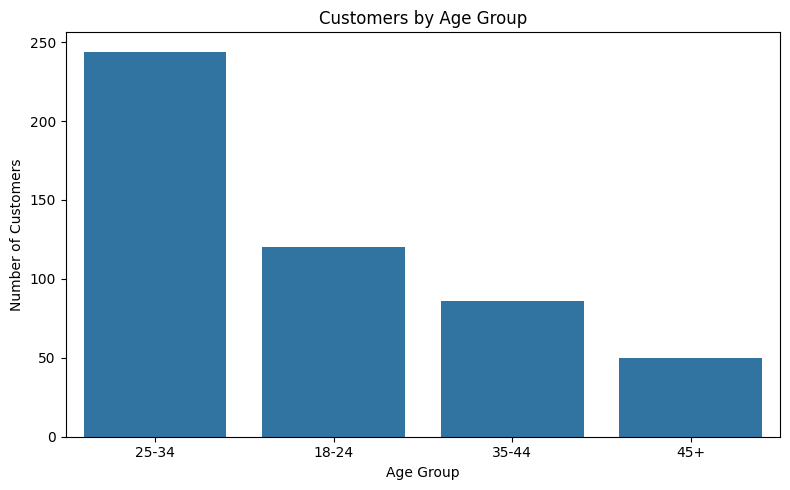

In [63]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=age_group_customers,
    x='age_group',
    y='customer_count'
)

plt.title('Customers by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

Q3.**Which acquisition channel brings the most customers?** (Customers by Acquisition Channel)

In [64]:
acquisition_channel = (
    customers['acquisition_channel']
    .value_counts()
    .reset_index()
)

acquisition_channel.columns = [
    'acquisition_channel',
    'customer_count'
]

acquisition_channel

,acquisition_channel,customer_count
0,Google Search,148
1,Instagram,145
2,YouTube,78
3,Website Direct,70
4,Referral,59


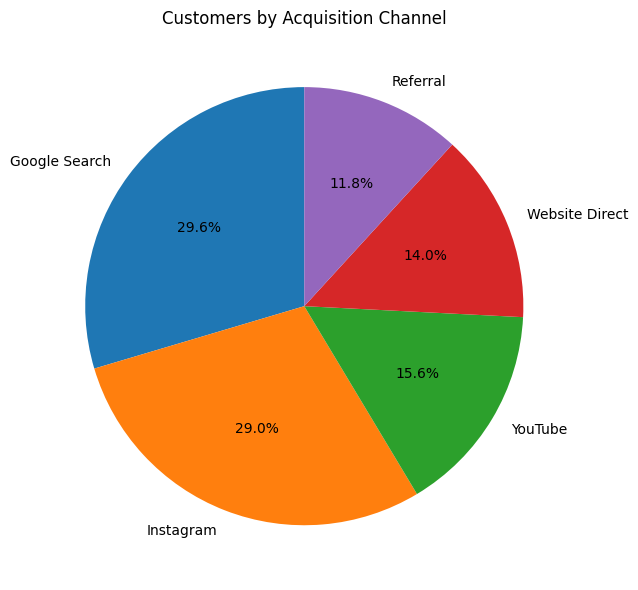

In [65]:
plt.figure(figsize=(8, 6))

plt.pie(
    acquisition_channel['customer_count'],
    labels=acquisition_channel['acquisition_channel'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Customers by Acquisition Channel')
plt.tight_layout()
plt.show()

**Q4.Which products generate the highest sales?** (Top 10 Products by Sales)

In [66]:
top_products = (
    sales_df.groupby('product_name')['item_sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products

,product_name,item_sales
0,Alpha Arbutin 2% Serum,107734
1,10% Niacinamide Face Serum,86256
2,Vitamin C 10% Face Serum,80385
3,Hyaluronic Acid 2% Serum,79068
4,Hair Growth Actives Serum,69513
5,SPF 60 PA++++ Sunscreen,68862
6,Granactive Retinoid 2% Serum,65518
7,Retinol 0.3% Face Serum,62910
8,2% Salicylic Acid Face Serum,60939
9,AHA BHA 10% Exfoliating Serum,55221


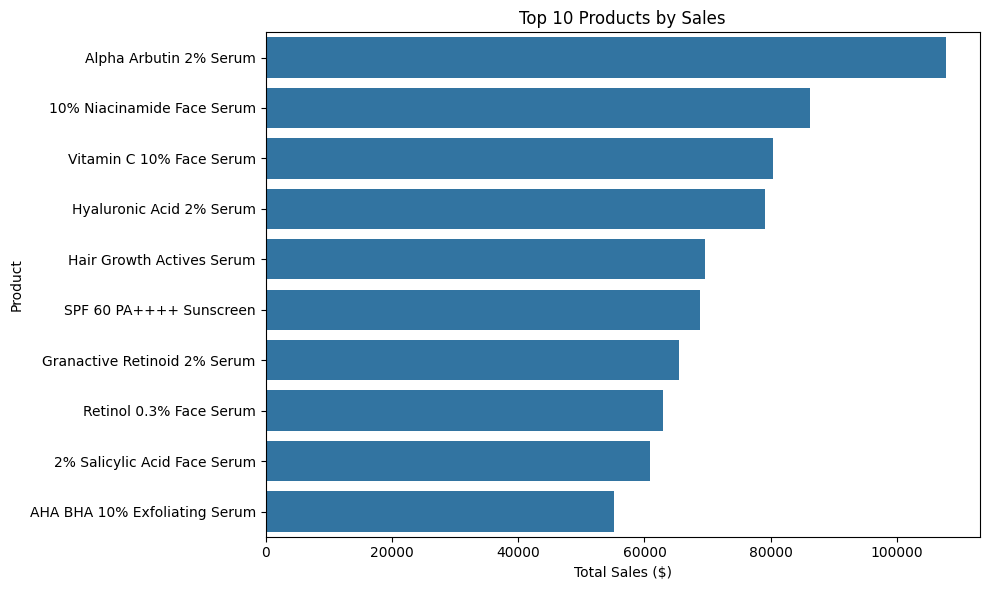

In [67]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_products,
    x='item_sales',
    y='product_name'
)

plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

Q5.**Which skin type has the highest product demand?** (Quantity Sold by Skin Type)

In [68]:
skin_type_quantity = (
    sales_df.groupby('skin_type')['quantity']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

skin_type_quantity

,skin_type,quantity
0,All Skin Types,888
1,Oily / Combination,317
2,Oily / Acne-Prone,266
3,Scalp Care,134
4,Dry / Dehydrated,132
5,Sensitive,129
6,Dry / Sensitive,124
7,Dry,116
8,Normal / Oily,115
9,Normal / Dry,90


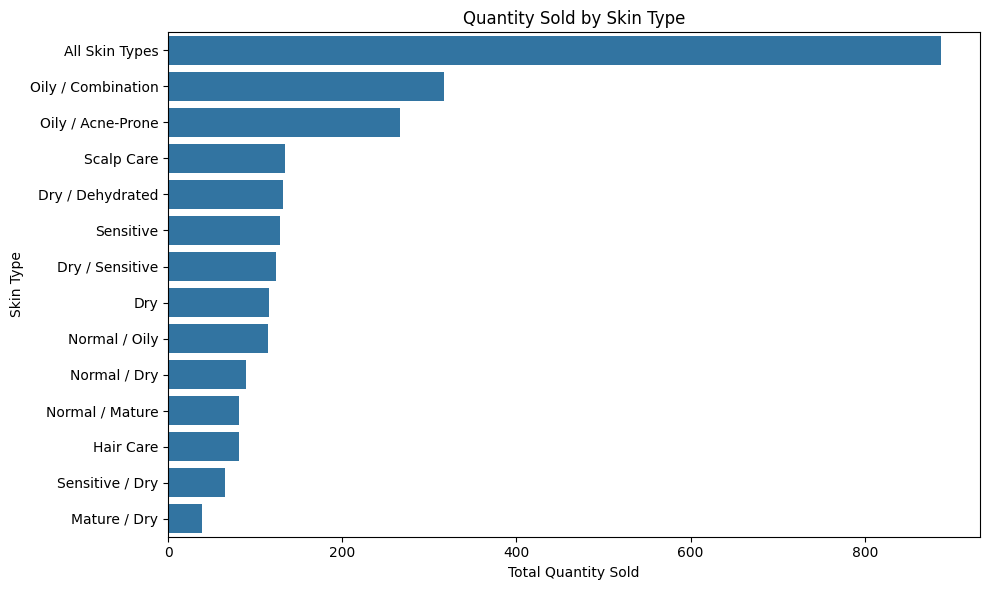

In [69]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=skin_type_quantity,
    x='quantity',
    y='skin_type'
)

plt.title('Quantity Sold by Skin Type')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Skin Type')

plt.tight_layout()
plt.show()

# **Returns & Customer Satisfaction Analysis 🔄⭐**

Q1.What is the overall return rate? ( Total Returns and Return Rate)

In [70]:
total_returns = returns['return_id'].nunique()

return_rate = (total_returns / total_orders) * 100

print(f"Total Returns: {total_returns}")
print(f"Return Rate: {return_rate:.2f}%")

Total Returns: 79
Return Rate: 6.32%


Q2.What percentage of orders were successfully delivered?
 (Delivered Order Percentage)

In [71]:
delivered_orders = (
    orders[orders['order_status'] == 'Delivered']['order_id']
    .nunique()
)

delivered_order_percentage = (
    delivered_orders / total_orders
) * 100

print(f"Delivered Orders: {delivered_orders}")
print(f"Delivered Order Percentage: {delivered_order_percentage:.2f}%")

Delivered Orders: 1020
Delivered Order Percentage: 81.60%


Q3.What are the most common reasons for product returns? ( Returns by Return Reason)

In [72]:
returns_by_reason = (
    returns['return_reason']
    .value_counts()
    .reset_index()
)

returns_by_reason.columns = ['return_reason', 'total_returns']

returns_by_reason

,return_reason,total_returns
0,Skin irritation,28
1,Late delivery,16
2,Damaged packaging,13
3,Wrong item received,12
4,Changed mind,10


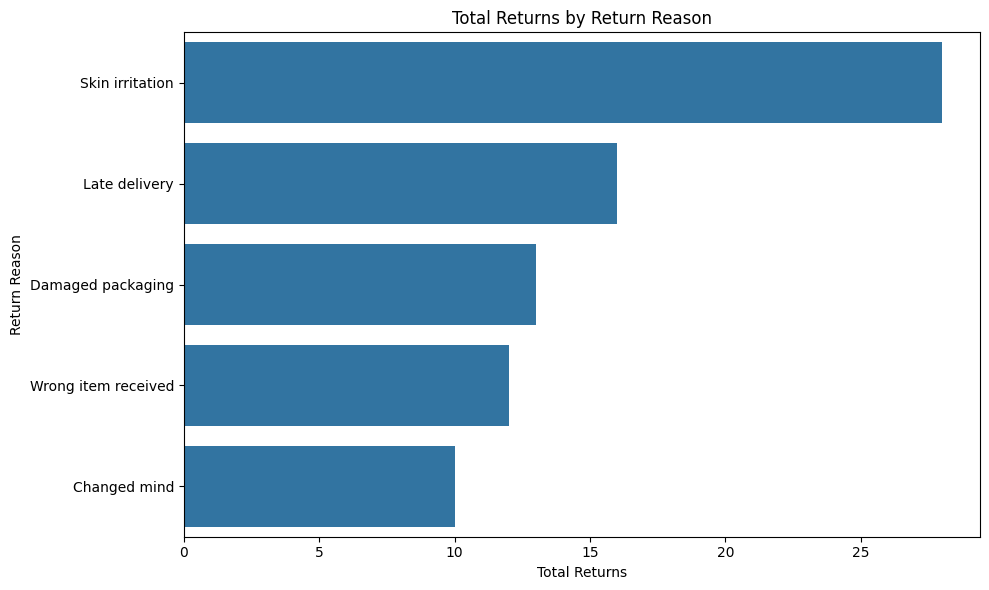

In [73]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=returns_by_reason,
    x='total_returns',
    y='return_reason'
)

plt.title('Total Returns by Return Reason')
plt.xlabel('Total Returns')
plt.ylabel('Return Reason')

plt.tight_layout()
plt.show()

Q4.Which product categories have the highest number of returns? (Returns by Product Category)

In [74]:
returns_by_category = (
    returns_df.groupby('category')['return_id']
    .count()
    .sort_values(ascending=False)
    .reset_index()
)

returns_by_category.columns = ['category', 'total_returns']

returns_by_category

,category,total_returns
0,Serum,34
1,Moisturizer,16
2,Cleanser,8
3,Sunscreen,6
4,Hair Care,6
5,Body Care,4
6,Eye Care,3
7,Lip Care,1
8,Toner,1


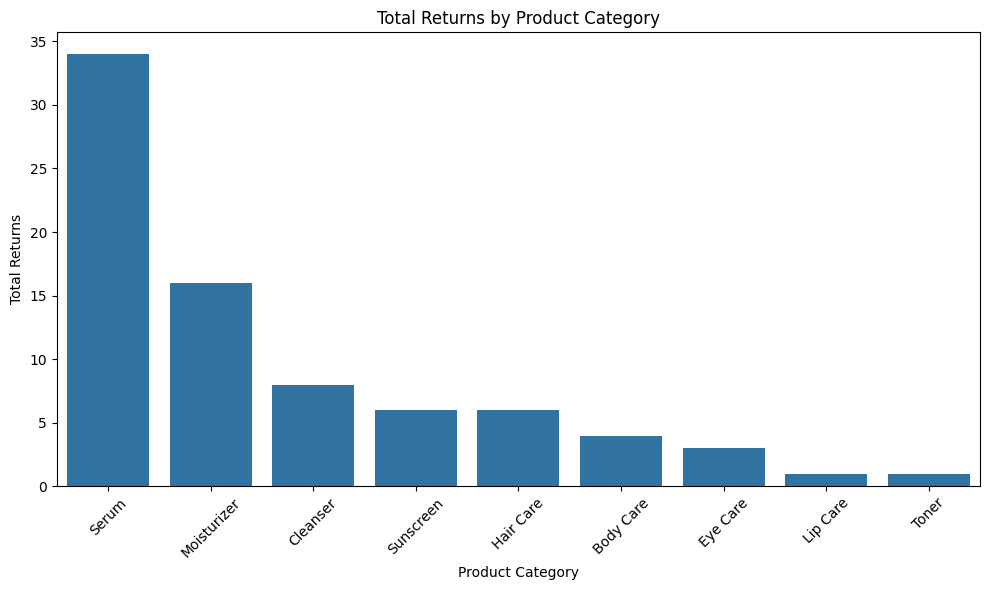

In [75]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=returns_by_category,
    x='category',
    y='total_returns'
)

plt.title('Total Returns by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Returns')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Q5.Which product categories receive the highest customer ratings? (Average Rating by Category)

In [76]:
average_rating_category = (
    reviews_df.groupby('category')['rating']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

average_rating_category.columns = ['category', 'average_rating']

average_rating_category

,category,average_rating
0,Moisturizer,4.139785
1,Cleanser,4.046154
2,Sunscreen,3.928571
3,Toner,3.882353
4,Lip Care,3.842105
5,Serum,3.813253
6,Hair Care,3.805556
7,Body Care,3.760000
8,Eye Care,3.705882


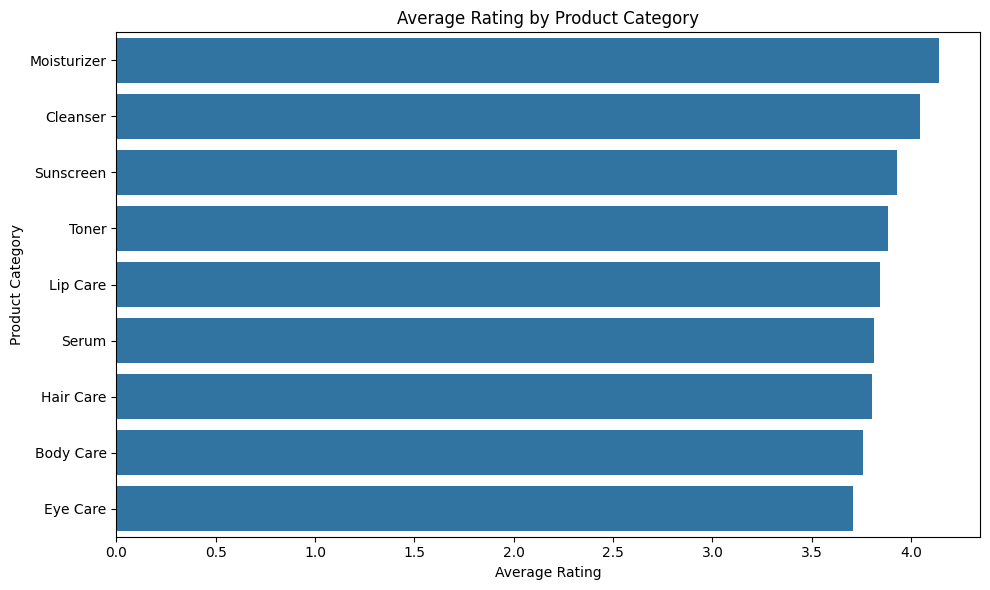

In [77]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=average_rating_category,
    x='average_rating',
    y='category'
)

plt.title('Average Rating by Product Category')
plt.xlabel('Average Rating')
plt.ylabel('Product Category')

plt.tight_layout()
plt.show()

Q6.How are customer ratings distributed? (Rating Distribution)

In [78]:
rating_distribution = (
    reviews['rating']
    .value_counts()
    .sort_index()
    .reset_index()
)

rating_distribution.columns = ['rating', 'review_count']

rating_distribution

,rating,review_count
0,1,29
1,2,39
2,3,70
3,4,163
4,5,193


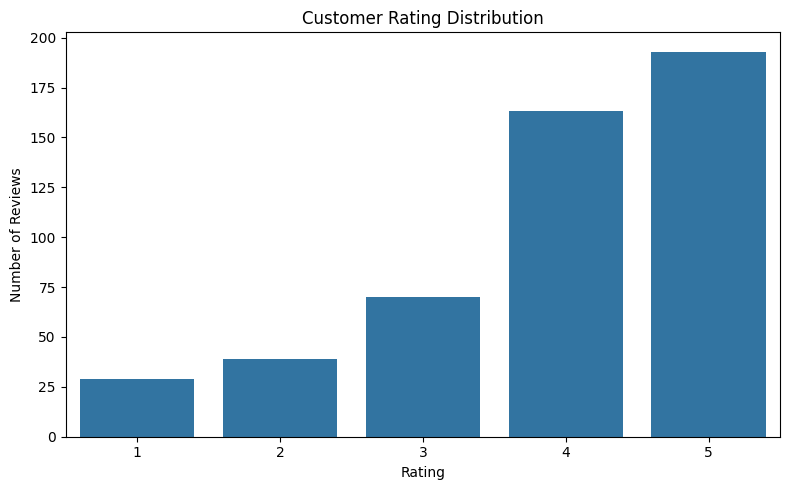

In [79]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=rating_distribution,
    x='rating',
    y='review_count'
)

plt.title('Customer Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')

plt.tight_layout()
plt.show()

Q7.What is the distribution of return refund statuses? (Returns by Refund Status)

In [80]:
refund_status = (
    returns['refund_status']
    .value_counts()
    .reset_index()
)

refund_status.columns = ['refund_status', 'total_returns']

refund_status

,refund_status,total_returns
0,Replacement Sent,28
1,Refunded,26
2,Under Review,25


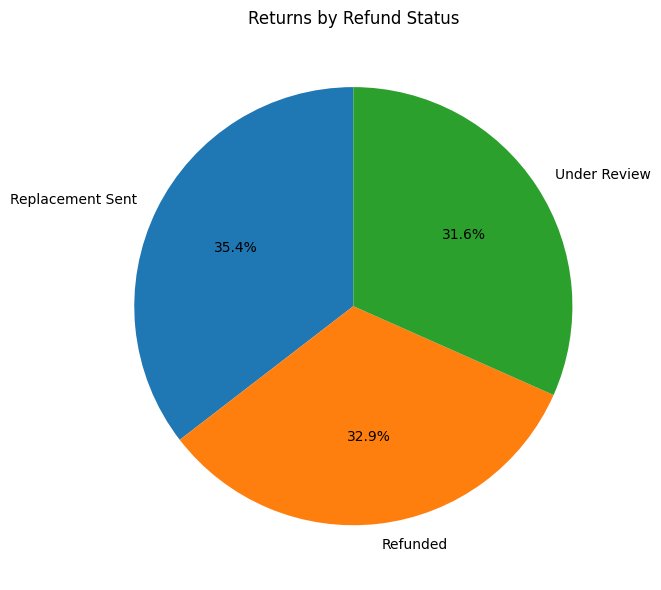

In [81]:
plt.figure(figsize=(8, 6))

plt.pie(
    refund_status['total_returns'],
    labels=refund_status['refund_status'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Returns by Refund Status')
plt.tight_layout()
plt.show()

# **Overall Average Rating**

In [82]:
average_rating = reviews['rating'].mean()

print(f"Average Customer Rating: {average_rating:.2f}")

Average Customer Rating: 3.91
